[문제 1]	Fashion	MNIST	데이터 정규화를 위한 Mean과	Std.	값 찾기

In [2]:
!pip install torchinfo

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def compute_mean_std_fashion_mnist(data_path):
    transform = transforms.ToTensor()
    dataset = datasets.FashionMNIST(
        root=data_path, train=True, download=True, transform=transform
    )

    loader = DataLoader(dataset, batch_size=10000, shuffle=False)

    n_pixels = 0
    sum_ = 0.0
    sum_sq = 0.0

    for images, _ in loader:
        # images: (B, 1, 28, 28)
        images = images.view(images.size(0), -1)  # (B, 784)
        n_pixels += images.numel()
        sum_ += images.sum().item()
        sum_sq += (images ** 2).sum().item()

    mean = sum_ / n_pixels
    var = (sum_sq / n_pixels) - (mean ** 2)
    std = var ** 0.5

    return mean, std

data_path = "_00_data/j_fashion_mnist"
mean, std = compute_mean_std_fashion_mnist(data_path)
print("mean:", mean)
print("std :", std)

mean: 0.28604059842687074
std : 0.3530242415539292


해석


*   transform = transforms.ToTensor() : 0-255 → 0-1 float 으로 변환
*   loader = DataLoader(dataset, batch_size=10000, shuffle=False) : 60,000장을 10,000장씩 6개 batch로 나눔
*   images = images.view(images.size(0), -1) : 픽셀을 1차원 배열로 만듦





취득한 기술적 사항/고찰 내용

*   per-image std와 global std이 차이가 난다는 점



[문제 2]	Fashion	MNIST	데이터에	대하여	CNN	학습시키기

In [6]:
import os
from datetime import datetime

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets
from torchvision.transforms import transforms

import wandb
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ───────────────────────────────
# 1. 문제1에서 구한 mean/std 값
# ───────────────────────────────
F_MEAN = 0.2860406
F_STD  = 0.35302424

DATA_PATH = "./data/fashion_mnist"   # Colab 현재 폴더 기준


# ───────────────────────────────
# 2. Transform을 따로 주기 위한 래퍼 Dataset
#    (train=aug, val/test=no-aug)
# ───────────────────────────────
class TransformDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, target = self.base_dataset[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, target


# ───────────────────────────────
# 3. DataLoader + Normalize
#    - Train: 55,000 (augmentation 적용)
#    - Val:   5,000
#    - Test: 10,000
# ───────────────────────────────
def get_fashion_mnist_loaders(batch_size: int):
    # 원본: PIL Image 로딩
    full_train_raw = datasets.FashionMNIST(
        root=DATA_PATH,
        train=True,
        download=True,
        transform=None,
    )

    # 재현성을 위한 시드
    generator = torch.Generator().manual_seed(42)
    train_subset, val_subset = random_split(full_train_raw, [55_000, 5_000], generator=generator)

    # 이미지 변환
    #   - Train: 회전만 약하게 추가 (과한 왜곡 방지)
    train_image_transform = transforms.Compose([
        transforms.RandomRotation(degrees=10),  # ±10도 이내 회전
        transforms.ToTensor(),
    ])

    #   - Val/Test: 증강 없이 ToTensor만
    val_test_image_transform = transforms.ToTensor()

    train_ds = TransformDataset(train_subset, train_image_transform)
    val_ds   = TransformDataset(val_subset, val_test_image_transform)

    test_raw = datasets.FashionMNIST(
        root=DATA_PATH,
        train=False,
        download=True,
        transform=None,
    )
    test_ds = TransformDataset(test_raw, val_test_image_transform)

    print("Num Train Samples:", len(train_ds))
    print("Num Validation Samples:", len(val_ds))
    print("Num Test Samples:", len(test_ds))

    num_workers = os.cpu_count() or 2
    print("Num workers:", num_workers)

    train_loader = DataLoader(
        dataset=train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        dataset=val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    test_loader = DataLoader(
        dataset=test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    # 입력 정규화 (문제1에서 구한 mean/std 사용)
    f_mnist_transforms = nn.Sequential(
        transforms.ConvertImageDtype(torch.float),
        transforms.Normalize(mean=F_MEAN, std=F_STD),
    )

    return train_loader, val_loader, test_loader, f_mnist_transforms


# ───────────────────────────────
# 4. 더 깊어진 VGG-ish Modern CNN
#    (Conv+BN+ReLU × 여러번, MaxPool, FC+Dropout)
# ───────────────────────────────
class FashionMNISTModernCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 1 x 28 x 28 → 64 x 14 x 14
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 64 x 14 x 14 → 128 x 7 x 7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 128 x 7 x 7 → 256 x 3 x 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 7 → 3
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                # 256 * 3 * 3 = 2304
            nn.Linear(256 * 3 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),             # FC dropout만 사용
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ───────────────────────────────
# 5. Accuracy 계산 함수
# ───────────────────────────────
def calc_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total


# ───────────────────────────────
# 6. 문제2: 학습 + WandB + torchinfo + Scheduler
# ───────────────────────────────
def train_fashion_mnist_cnn(
    epochs: int = 20,
    batch_size: int = 2048,
    learning_rate: float = 1e-3,
    use_wandb: bool = True,
):
    run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

    config = {
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "optimizer": "Adam",
        "weight_decay": 1e-5,          # 과규제 방지를 위해 줄임
        "dropout": 0.5,
        "model": "VGGish_3Blocks_ConvBNReLU + FC_Dropout",
        "dataset": "FashionMNIST",
        "input_normalization": {"mean": F_MEAN, "std": F_STD},
        "augmentation": "RandomRotation(±10°)",
        "scheduler": "StepLR(step_size=7, gamma=0.5)",
    }

    project_name = "fashion_mnist_hw3"

    wandb.init(
        mode="online" if use_wandb else "disabled",
        project=project_name,
        notes="HW3 Problem 2: tuned VGG-like CNN + mild aug",
        tags=["cnn", "fashion-mnist", "modern-cnn", "regularization", "normalization", "augmentation"],
        name=run_time_str,
        config=config,
    )

    train_loader, val_loader, test_loader, f_mnist_transforms = get_fashion_mnist_loaders(
        batch_size=batch_size
    )

    # 모델 생성 + torchinfo summary 출력
    model = FashionMNISTModernCNN(in_channels=1, num_classes=10)
    summary(model, input_size=(1, 1, 28, 28))   # 문제에서 요구한 torchinfo 출력
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=config["weight_decay"],
    )

    # Learning Rate Scheduler
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=7, gamma=0.5
    )

    best_val_acc = 0.0

    for epoch in range(epochs):
        # ───── Training ─────
        model.train()
        running_train_loss = 0.0
        running_train_correct = 0
        running_train_total = 0

        for inputs, targets in train_loader:
            inputs = f_mnist_transforms(inputs).to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            bs = targets.size(0)
            running_train_loss += loss.item() * bs
            running_train_correct += (outputs.argmax(dim=1) == targets).sum().item()
            running_train_total += bs

        train_loss = running_train_loss / running_train_total
        train_acc = running_train_correct / running_train_total

        # ───── Validation ─────
        model.eval()
        running_val_loss = 0.0
        running_val_correct = 0
        running_val_total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = f_mnist_transforms(inputs).to(device)
                targets = targets.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)

                bs = targets.size(0)
                running_val_loss += loss.item() * bs
                running_val_correct += (outputs.argmax(dim=1) == targets).sum().item()
                running_val_total += bs

        val_loss = running_val_loss / running_val_total
        val_acc = running_val_correct / running_val_total

        best_val_acc = max(best_val_acc, val_acc)

        # 스케줄러 한 스텝 진행
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        print(
            f"[Epoch {epoch + 1}/{epochs}] "
            f"lr={current_lr:.6f} | "
            f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
        )

        # 문제에서 요구한 4개 지표 + lr WandB 로깅
        wandb.log({
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "lr": current_lr,
            "epoch": epoch + 1,
        })

    print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    wandb.finish()

    # 문제 3에서 Test Accuracy 계산할 때 쓰려고 모델/로더/transform 리턴
    return model, test_loader, f_mnist_transforms


# 문제 2 최종 실행
model, test_loader, f_mnist_transforms = train_fashion_mnist_cnn(
    epochs=20,
    batch_size=2048,
    learning_rate=1e-3,
    use_wandb=True,
)

Device: cuda


Num Train Samples: 55000
Num Validation Samples: 5000
Num Test Samples: 10000
Num workers: 2
[Epoch 1/20] lr=0.001000 | train_loss=0.8981, val_loss=0.5439, train_acc=0.6722, val_acc=0.8102
[Epoch 2/20] lr=0.001000 | train_loss=0.4375, val_loss=0.3672, train_acc=0.8389, val_acc=0.8660
[Epoch 3/20] lr=0.001000 | train_loss=0.3565, val_loss=0.3107, train_acc=0.8707, val_acc=0.8824
[Epoch 4/20] lr=0.001000 | train_loss=0.3022, val_loss=0.2764, train_acc=0.8905, val_acc=0.8972
[Epoch 5/20] lr=0.001000 | train_loss=0.2750, val_loss=0.2745, train_acc=0.9001, val_acc=0.9018
[Epoch 6/20] lr=0.001000 | train_loss=0.2525, val_loss=0.2508, train_acc=0.9086, val_acc=0.9046
[Epoch 7/20] lr=0.000500 | train_loss=0.2362, val_loss=0.2247, train_acc=0.9134, val_acc=0.9138
[Epoch 8/20] lr=0.000500 | train_loss=0.2117, val_loss=0.2116, train_acc=0.9238, val_acc=0.9226
[Epoch 9/20] lr=0.000500 | train_loss=0.2009, val_loss=0.2036, train_acc=0.9272, val_acc=0.9248
[Epoch 10/20] lr=0.000500 | train_loss=0.19

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,██████▃▃▃▃▃▃▃▁▁▁▁▁▁▁
train_acc,▁▅▆▆▇▇▇▇▇▇▇█████████
train_loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▆▆▇▇▇▇▇██▇██████
val_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch,20
lr,0.00025
train_acc,0.9548
train_loss,0.12781
val_acc,0.9404


In [9]:
from torchinfo import summary

# 이미 학습이 끝난 model을 그대로 사용
summary(model, input_size=(1, 1, 28, 28), device=str(device))

Layer (type:depth-idx)                   Output Shape              Param #
FashionMNISTModernCNN                    [1, 10]                   --
├─Sequential: 1-1                        [1, 256, 3, 3]            --
│    └─Conv2d: 2-1                       [1, 64, 28, 28]           640
│    └─BatchNorm2d: 2-2                  [1, 64, 28, 28]           128
│    └─ReLU: 2-3                         [1, 64, 28, 28]           --
│    └─Conv2d: 2-4                       [1, 64, 28, 28]           36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 28, 28]           128
│    └─ReLU: 2-6                         [1, 64, 28, 28]           --
│    └─MaxPool2d: 2-7                    [1, 64, 14, 14]           --
│    └─Conv2d: 2-8                       [1, 128, 14, 14]          73,856
│    └─BatchNorm2d: 2-9                  [1, 128, 14, 14]          256
│    └─ReLU: 2-10                        [1, 128, 14, 14]          --
│    └─Conv2d: 2-11                      [1, 128, 14, 14]          147,58

해석


*   Optimizer : Adam
*   Learning Rate : 1e-3
*   Scheduler : StepLR(step_size=7, gamma=0.5)
*   Weight Decay : 1e-5
*   Batch Size : 2048
*   Epochs : 20
*   Dropout : 0.5 (Fully Connected layer에 적용)
*   Random Rotation : ±10
*   Early Stop Patience : X
*   FashionMNIST 전체 픽셀 분포 기반 Global Standard Normalization 적용 + Batch Normalization(BN) 사용하여 층 단위 정규화 수행
*   FashionMNISTModernCNN : VGG 스타일 CNN 구조

취득한 기술적 사항/고찰 내용

*   Fashion-MNIST는 augmentation 효과가 매우 큼
*   적당히 많은 Conv 레이어는 정확도 향상에 도움이 됨

[문제 3]	학습 완료된 모델로 테스트 데이터 Accuracy	확인하기

In [7]:
# 문제 3: Test Accuracy 계산
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = f_mnist_transforms(images).to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print("Test Accuracy:", test_acc * 100)

Test Accuracy: 93.26


해석


*   with torch.no_grad(): gradient 계산 비활성화
*   f_mnist_transforms : 계산한 평균/표준편차로 Normalize하는 단계

취득한 기술적 사항/고찰 내용

*   model.eval()은 Dropout, BatchNorm 같은 학습 전용 레이어를 평가 모드로 변경하여 테스트 시 반드시 필요하다는 점

[문제 4]	샘플 테스트 데이터 분류 예측 결과 확인하기

Test dataset size: 10000
Num correct samples : 9326
Num wrong samples   : 674


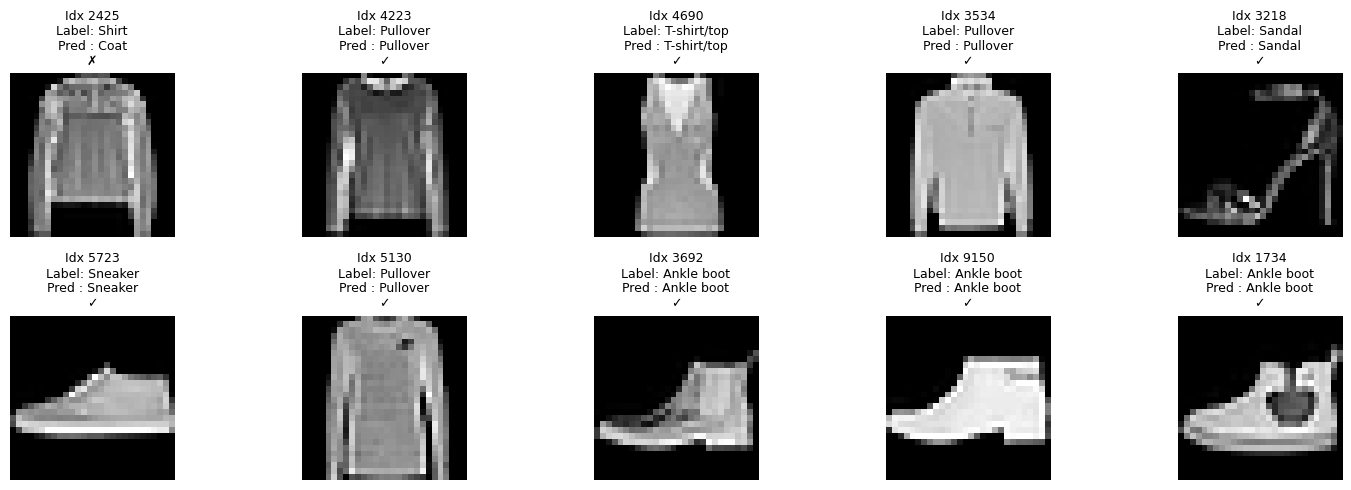

In [8]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random

model.eval()  # 평가 모드

# Fashion-MNIST 클래스 이름 (공식 순서)
class_names = [
    "T-shirt/top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle boot",   # 9
]

# 1) 테스트 데이터 (10,000개) 로드 (ToTensor만 적용)
test_dataset_for_vis = datasets.FashionMNIST(
    root=DATA_PATH,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print("Test dataset size:", len(test_dataset_for_vis))  # 10000일 것

# 2) 전체 테스트 데이터에서 정답/오답 인덱스 분리
correct_indices = []
wrong_indices = []

with torch.no_grad():
    for idx in range(len(test_dataset_for_vis)):
        img, label = test_dataset_for_vis[idx]   # img: [1, 28, 28]
        input_img = f_mnist_transforms(img.unsqueeze(0)).to(device)  # [1,1,28,28]

        outputs = model(input_img)
        pred = outputs.argmax(1).item()

        if pred == label:
            correct_indices.append(idx)
        else:
            wrong_indices.append(idx)

print("Num correct samples :", len(correct_indices))
print("Num wrong samples   :", len(wrong_indices))

# 3) 최소 1개는 오답, 나머지는 정답으로 10개 샘플 구성
#    (오답이 너무 적을 경우를 대비해서 min() 사용)
num_total = 10
num_wrong_to_show = 1
num_correct_to_show = num_total - num_wrong_to_show

chosen_wrong = random.sample(wrong_indices, k=num_wrong_to_show)
chosen_correct = random.sample(correct_indices, k=num_correct_to_show)

chosen_indices = chosen_wrong + chosen_correct
random.shuffle(chosen_indices)  # 섞어서 섞인 순서로 보여주기

# 4) 이미지, 정답 레이블, 예측 레이블 출력
plt.figure(figsize=(15, 5))

for i, idx in enumerate(chosen_indices):
    img, label = test_dataset_for_vis[idx]
    input_img = f_mnist_transforms(img.unsqueeze(0)).to(device)

    with torch.no_grad():
        outputs = model(input_img)
        pred = outputs.argmax(1).item()

    label_name = class_names[label]
    pred_name = class_names[pred]
    is_correct = (label == pred)

    # subplot에 이미지 출력
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(img.squeeze(0), cmap="gray")
    plt.axis("off")

    # 제목에 정답/예측/맞았는지 표시
    title = f"Idx {idx}\nLabel: {label_name}\nPred : {pred_name}"
    if is_correct:
        title += "\n✓"
    else:
        title += "\n✗"
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

해석


*   Label은 Shirt인데 Pred는 Coat로 잘못 예측됨. 이는 이미지 상으로 상의의 길이와 모양이 Shirt와 유사하고, 배경/밝기 정보가 단순해서 모델이 두 클래스를 구분하기 어려웠던 것으로 보인다.

취득한 기술적 사항/고찰 내용

*   서로 유사한 클래스끼리 오류가 발생하는 패턴이 존재함

숙제 후기

*   Validation	Accuracy을	94.0% 이상으로 맞추는 과정이 가장 오래 걸렸다. 하이퍼파라미터 수치를 조금씩 조작할 때마다 과적합이나 부적합으로 인해 Validation	Accuracy가 91~3%으로 계산될 때마다 고통스러웠다.  